# Titanic — Rede Neural MLP (PyTorch + Sklearn)
**Classificação Binária de Sobrevivência**

Qual é o objetivo do modelo (prever a sobrevivência)

Desafios: dados desbalanceados (61% vs 38%), missing values em Age e Cabin, variáveis categóricas negrito

Fonte: Kaggle Titanic Competition
Formato: CSV, 891 linhas, 12 colunas

## 1. Imports e Carregamento dos Dados

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier


import warnings
warnings.filterwarnings('ignore')

data_treino = pd.read_csv('train.csv')
print(f"Shape: {data_treino.shape}")
data_treino.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Exploração Rápida

In [33]:
print("Valores Faltantes")
print(data_treino.isnull().sum())

print("\nDistribuição do Target")
print(data_treino['Survived'].value_counts())

Valores Faltantes
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Distribuição do Target
Survived
0    549
1    342
Name: count, dtype: int64


## 3. Limpeza e Preparação Básica
>

In [34]:
data_treino['FamilySize'] = data_treino['SibSp'] + data_treino['Parch']
data_treino['Age'].fillna(data_treino['Age'].mean(), inplace=True)
data_treino['Fare'].replace(0, data_treino['Fare'].median(), inplace=True)
data_treino['Age'] = data_treino['Age'].astype(int)
data_treino['Sex'] = data_treino['Sex'].map({'male': 0, 'female': 1})
most_common_embarked = data_treino['Embarked'].mode()[0]
data_treino['Embarked'].fillna(most_common_embarked, inplace=True)
data_treino['Embarked'] = data_treino['Embarked'].map({'C': 1, 'Q': 2, 'S': 3})
data_treino.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], axis=1, inplace=True)

print("Dados após limpeza:")
print(data_treino.head())
print(f"\nShape final: {data_treino.shape}")

Dados após limpeza:
   Survived  Pclass  Sex  Age     Fare  Embarked  FamilySize
0         0       3    0   22   7.2500         3           1
1         1       1    1   38  71.2833         1           1
2         1       3    1   26   7.9250         3           0
3         1       1    1   35  53.1000         3           1
4         0       3    0   35   8.0500         3           0

Shape final: (891, 7)


## 4. Separar Treino e Teste (Antes de Qualquer Aumento)
>


In [35]:
df_train, df_test = train_test_split(data_treino, test_size=0.2, random_state=4)

X_train = df_train.drop('Survived', axis=1)
y_train = df_train['Survived']
X_test  = df_test.drop('Survived', axis=1)
y_test  = df_test['Survived']

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 712 amostras | Teste: 179 amostras


## 5. Pré-processamento (StandardScaler)

In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Tensores para PyTorch
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values.reshape(-1,1), dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values.reshape(-1,1),  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

## 6. Modelo MLP (PyTorch)


In [37]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32, hidden_size3=16, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size1), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_size1, hidden_size2), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_size2, hidden_size3), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_size3, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

# Hiperparâmetros (mantidos)
input_size    = X_train.shape[1]
learning_rate = 0.001
num_epochs    = 1000
weight_decay  = 1e-4

model     = MLP(input_size)
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


## 7. Treinamento

In [38]:
train_losses, test_losses = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    model.eval()
    with torch.no_grad():
        test_losses.append(criterion(model(X_test_t), y_test_t).item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f}")

Epoch [100/1000] | Train Loss: 0.1779 | Test Loss: 0.1669
Epoch [200/1000] | Train Loss: 0.1671 | Test Loss: 0.1636
Epoch [300/1000] | Train Loss: 0.1596 | Test Loss: 0.1664
Epoch [400/1000] | Train Loss: 0.1696 | Test Loss: 0.1535
Epoch [500/1000] | Train Loss: 0.1641 | Test Loss: 0.1489
Epoch [600/1000] | Train Loss: 0.1669 | Test Loss: 0.1491
Epoch [700/1000] | Train Loss: 0.1590 | Test Loss: 0.1478
Epoch [800/1000] | Train Loss: 0.1610 | Test Loss: 0.1490
Epoch [900/1000] | Train Loss: 0.1620 | Test Loss: 0.1462
Epoch [1000/1000] | Train Loss: 0.1527 | Test Loss: 0.1465


## 8. Curva de Perda

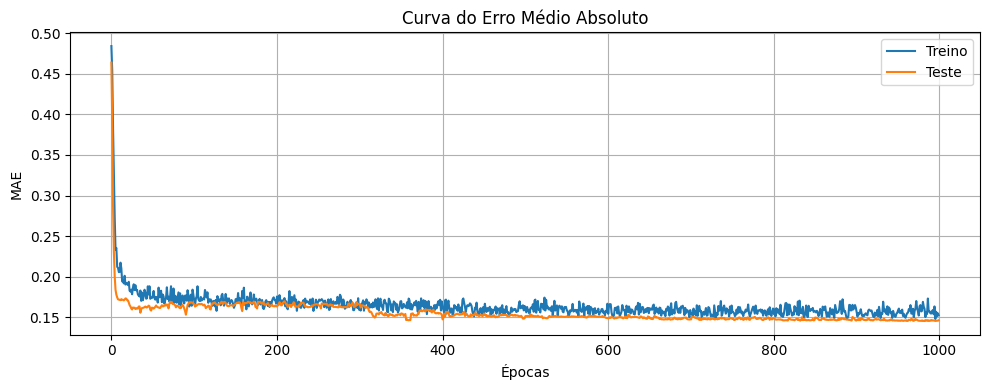

In [39]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Treino')
plt.plot(test_losses,  label='Teste')
plt.title('Curva do Erro Médio Absoluto')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 9. Avaliação — Modelo PyTorch

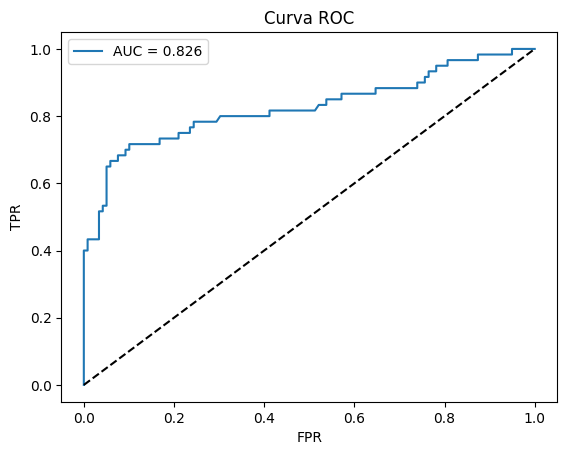


Teste
Acurácia: 0.8547
                precision    recall  f1-score   support

Não Sobreviveu       0.85      0.95      0.90       119
    Sobreviveu       0.87      0.67      0.75        60

      accuracy                           0.85       179
     macro avg       0.86      0.81      0.83       179
  weighted avg       0.86      0.85      0.85       179



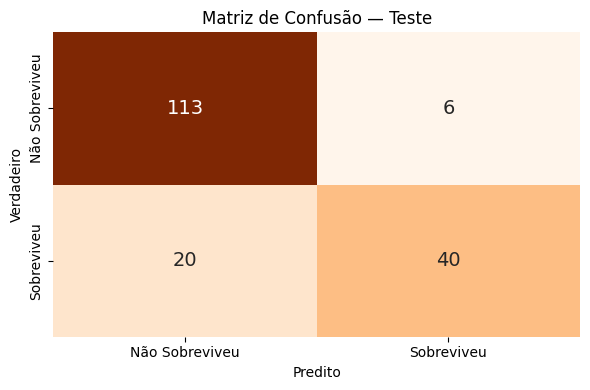


Treino
Acurácia: 0.8455
                precision    recall  f1-score   support

Não Sobreviveu       0.83      0.94      0.88       430
    Sobreviveu       0.88      0.70      0.78       282

      accuracy                           0.85       712
     macro avg       0.86      0.82      0.83       712
  weighted avg       0.85      0.85      0.84       712



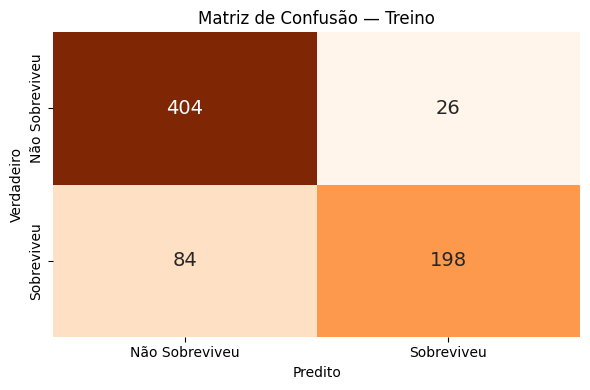

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score # Added for fix

def avaliar(model, X_t, y_t, titulo):
    model.eval()
    with torch.no_grad():
        y_pred = torch.round(model(X_t)).numpy()
    y_true = y_t.numpy()
    acc = accuracy_score(y_true, y_pred)
    cm  = confusion_matrix(y_true, y_pred)
    print(f"\n{titulo}")
    print(f"Acurácia: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=['Não Sobreviveu','Sobreviveu']))
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False, annot_kws={"size":14},
                xticklabels=['Não Sobreviveu','Sobreviveu'],
                yticklabels=['Não Sobreviveu','Sobreviveu'])
    plt.title(f'Matriz de Confusão — {titulo}')
    plt.xlabel('Predito'); plt.ylabel('Verdadeiro')
    plt.tight_layout(); plt.show()
    return acc


y_prob = model_sk.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend(); plt.show()

acc_test  = avaliar(model, X_test_t,  y_test_t,  'Teste')
acc_train = avaliar(model, X_train_t, y_train_t, 'Treino')

## 10. Modelo Simplificado — MLPClassifier (sklearn)
Mesma arquitetura, menos código

In [41]:
model_sk = MLPClassifier(hidden_layer_sizes=(64, 32, 16), max_iter=1000, random_state=42)
model_sk.fit(X_train_scaled, y_train)

y_pred_sk = model_sk.predict(X_test_scaled)
print(f"Acurácia (sklearn MLP): {accuracy_score(y_test, y_pred_sk):.4f}")
print(classification_report(y_test, y_pred_sk, target_names=['Não Sobreviveu','Sobreviveu']))

Acurácia (sklearn MLP): 0.8324
                precision    recall  f1-score   support

Não Sobreviveu       0.85      0.91      0.88       119
    Sobreviveu       0.79      0.68      0.73        60

      accuracy                           0.83       179
     macro avg       0.82      0.80      0.81       179
  weighted avg       0.83      0.83      0.83       179



## 11. Importância das Features

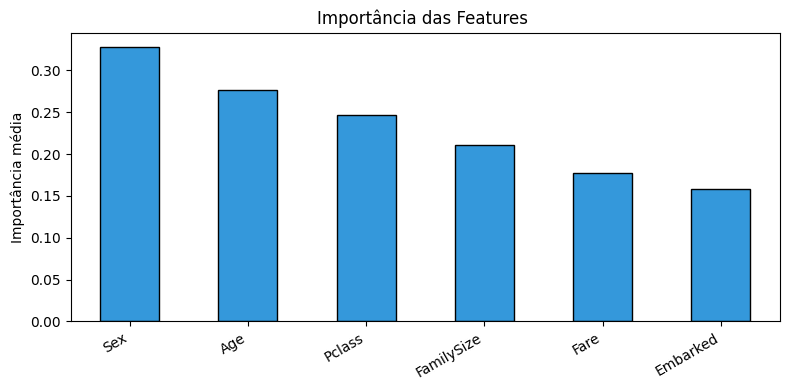

Sex           0.328406
Age           0.276746
Pclass        0.247069
FamilySize    0.211248
Fare          0.177330
Embarked      0.158803
dtype: float32


In [42]:
importances = np.mean(np.abs(model.net[0].weight.detach().numpy()), axis=0)
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(8, 4), color='#3498db', edgecolor='black')
plt.title('Importância das Features ')
plt.ylabel('Importância média')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(feat_imp)

## 12. Salvar o Modelo

In [43]:
import pickle

with open('titanic_mlp.pkl', 'wb') as f:
    pickle.dump({'model_sklearn': model_sk, 'scaler': scaler,
                 'features': list(X_train.columns)}, f)

torch.save(model.state_dict(), 'titanic_mlp_pytorch.pth')

print("Modelos salvos: titanic_mlp.pkl  |  titanic_mlp_pytorch.pth")
print(f"\nAcurácia Final (PyTorch) : {acc_test:.4f}")
print(f"Acurácia Final (sklearn) : {accuracy_score(y_test, y_pred_sk):.4f}")

Modelos salvos: titanic_mlp.pkl  |  titanic_mlp_pytorch.pth

Acurácia Final (PyTorch) : 0.8547
Acurácia Final (sklearn) : 0.8324
